In [1]:
# https://paperswithcode.com/search?q_meta=&q_type=&q=semi+supervised+anomaly+detection

### SSLAL
- This notebook experiments how label spreading improves the performance for  semi-supervised techniques.
- The goal is to simulate a scenario where a model is trained iteratively by selecting the most informative data points to label [tehy are randomly selected in this scenario], and using **Label Spreading** to propagate labels from a small set of labeled data to a larger set of unlabeled data.

The approach includes the following steps:
- we start by randomly selecting a small fraction of labeled data points from the dataset.
- Then, we apply active learning to iteratively select the most uncertain or informative data points (to be changed in future, as at now it just random) for labeling.
   - In the semi-supervised learning process, we use **Label Spreading**, to propagates labels from a small set of labeled points to the unlabeled data points, based on their similarity.
   - This helps in cleaning the dataset by removing outliers and refining the model's training data.
   - The model's performance is evaluated using metrics like **ROC-AUC**, where we have both with spreading and not spreading
   - We vary the fraction of labeled data and observe how the model’s performance (ROC-AUC) changes with different amounts of labeled and unlabeled data.




In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.semi_supervised import LabelSpreading, LabelPropagation
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns


from pyod.models.pca import PCA
from pyod.models.ocsvm import OCSVM
from pyod.models.lof import LOF
from pyod.models.cof import COF
from pyod.models.hbos import HBOS
from pyod.models.knn import KNN
from pyod.models.sod import SOD
from pyod.models.copod import COPOD
from pyod.models.ecod import ECOD
from pyod.models.iforest import IForest
from pyod.models.loda import LODA
from pyod.models.kde import KDE
from pyod.models.cblof import CBLOF


import warnings
warnings.filterwarnings("ignore")


In [3]:
model_dict = {
    'PCA': PCA,
    'OCSVM': OCSVM,
    'LOF': LOF,
    'COF': COF,
    'HBOS': HBOS,
    'KNN': KNN,
    'SOD': SOD,
    'COPOD': COPOD,
    'ECOD': ECOD,
    'IForest': IForest,
    'LODA': LODA,
    'KDE': KDE,
    'CBLOF': CBLOF
}

In [4]:
def prepare_data(X, y, num_samples, frac, random_state=42):
    _, Xsamp, _, ysamp = train_test_split(X, y, test_size=num_samples / X.shape[0], 
                                           random_state=random_state, stratify=y)

    X_train, X_test, y_train, y_test = train_test_split(Xsamp, ysamp, test_size=0.5,                                                         
                                                        random_state=random_state, stratify=ysamp)


    if frac > 0:
        # lbl spreading to remove outliers
        label_spread_model = LabelSpreading()
        rng = np.random.RandomState(random_state)
        random_unlabeled_points = rng.rand(len(y_train)) > frac
        labels = np.copy(y_train)
        #unlabeleld with -1
        labels[random_unlabeled_points] = -1

        # Check if we have enough labeled points before fitting
        if np.sum(labels != -1) < 2:
            print(f"Warning: Not enough labeled points after applying fraction {frac}. Skipping label spreading.")
            return X_train, X_train, y_train, y_train, X_test, y_test  # Return data without label spreading
            return 
        
            
        label_spread_model.fit(X_train, labels)
        # get predicted probabilities for outliers
        label_proba = label_spread_model.predict_proba(X_train)

        # remove outliers based on probability threshold
        random_values = rng.rand(len(y_train))
        remove_idx_prop = np.where(label_proba[:, 0] < random_values)[0]
        X_train_prop = np.delete(X_train, remove_idx_prop, axis=0)
        y_train_prop = np.delete(y_train, remove_idx_prop)

        # remove points that are labeled as "not outliers" (i.e., labeled as 1)
        remove_idx_noprop = np.where(labels == 1)[0]
        X_train_noprop = np.delete(X_train, remove_idx_noprop, axis=0)
        y_train_noprop = np.delete(y_train, remove_idx_noprop)
    else:
        # no label spreading, use full data
        X_train_prop = X_train
        y_train_prop = y_train
        X_train_noprop = X_train
        y_train_noprop = y_train

    return X_train_prop, X_train_noprop, y_train_prop, y_train_noprop, X_test, y_test


In [5]:

def train_and_evaluate(X_train_prop, X_train_noprop, y_train_prop, y_train_noprop, X_test, y_test, model, model_name, params={}):
    detector_prop = model(**params)
    detector_noprop = model(**params)

    # train both models
    detector_prop.fit(X_train_prop)
    detector_noprop.fit(X_train_noprop)

    # get outlier scores (decision function)
    X_test_scores_prop = detector_prop.decision_function(X_test)
    X_test_scores_noprop = detector_noprop.decision_function(X_test)

    # find ROC-AUC scores
    try:
        roc_auc_prop = roc_auc_score(y_test, X_test_scores_prop)
        roc_auc_noprop = roc_auc_score(y_test, X_test_scores_noprop)
    except ValueError as e:
        print(f"Error occured while getting the auc values : e={e}")
        # handle error cases where AUC cannot be calculated E.G single class in the test set
        roc_auc_prop = np.nan
        roc_auc_noprop = np.nan

    return roc_auc_prop, roc_auc_noprop



In [6]:
def run_experiment(X, y, model, model_name, num_samples=1000, fractions=None, random_state=42, reps=5, params={}):
    # init result DataFrames
    all_results_prop = pd.DataFrame()
    all_results_noprop = pd.DataFrame()

    # loop over different fractions of outliers
    for frac in tqdm(fractions):
        for rep in range(reps):
            # prepare data with different outlier fractions
            try:
                X_train_prop, X_train_noprop, y_train_prop, y_train_noprop, X_test, y_test = prepare_data(
                    X, y, num_samples, frac, random_state=random_state + rep)
    
                # train and evaluate the model
                roc_auc_prop, roc_auc_noprop = train_and_evaluate(
                    X_train_prop, X_train_noprop, y_train_prop, y_train_noprop, X_test, y_test, model, model_name, params
                )
    
                # store results for label spreading and no label spreading models
                result_prop = {'method': 'Spreading', 'dataset': dataset, 'model': model_name, 'roc_auc': roc_auc_prop, 'fraction': frac, 'rep': rep}
                result_df_prop = pd.DataFrame(result_prop, index=[0])
                all_results_prop = pd.concat([all_results_prop, result_df_prop])
    
                result_noprop = {'method': 'No Spreading', 'dataset': dataset,'model': model_name, 'roc_auc': roc_auc_noprop, 'fraction': frac, 'rep': rep}
                result_df_noprop = pd.DataFrame(result_noprop, index=[0])
                all_results_noprop = pd.concat([all_results_noprop, result_df_noprop])
            except Exception as e:
                print(f"Error: {e} at model={model_name}, ")

    return all_results_prop, all_results_noprop



In [7]:
model_dict, len(model_dict)

({'PCA': pyod.models.pca.PCA,
  'OCSVM': pyod.models.ocsvm.OCSVM,
  'LOF': pyod.models.lof.LOF,
  'COF': pyod.models.cof.COF,
  'HBOS': pyod.models.hbos.HBOS,
  'KNN': pyod.models.knn.KNN,
  'SOD': pyod.models.sod.SOD,
  'COPOD': pyod.models.copod.COPOD,
  'ECOD': pyod.models.ecod.ECOD,
  'IForest': pyod.models.iforest.IForest,
  'LODA': pyod.models.loda.LODA,
  'KDE': pyod.models.kde.KDE,
  'CBLOF': pyod.models.cblof.CBLOF},
 13)

In [24]:

# for a single plot
def plot_single_results_with_uncertainty(all_results_prop, all_results_noprop, fractions, model_name, dataset):
    all_results_prop['method'] = 'Spreading'
    all_results_noprop['method'] = 'No Spreading'

    all_results = pd.concat([all_results_prop, all_results_noprop])

    plt.figure(figsize=(15, 10))
    
    sns.lineplot(x='fraction', y='roc_auc', data=all_results, errorbar='sd', hue='method', style='method')

    plt.title(f'{model_name} on {dataset}, Random Querying')
    plt.ylabel('AUC')
    plt.xlabel('% labels queried')

    ax = plt.gca()
    ax.set_xticks(fractions)
    ax.set_xticklabels([f'{x*100:.0f}%' if x >= 0.1 or x == 0 else '' for x in fractions])

    plt.xlim(-.01, 1.01)

    plt.legend(title='Method')
    plt.tight_layout()
    plt.show()

# grid
import math
def plot_results_grid(all_results, fractions, model_dict, datasets):
    num_datasets = len(datasets)
    num_models = len(model_dict)
    
    for i, dataset in enumerate(datasets):
        cols = 4 #we have 4 cols
        rows = math.ceil(num_models/cols)
        
        fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
        axes = axes.flatten()  # Flatten to make it easier to index axes

        for j, (model_name, model) in enumerate(model_dict.items()):
            # filter the results for the current dataset and model
            dataset_model_results = all_results[(all_results['dataset'] == dataset) & (all_results['model'] == model_name)].dropna().reset_index(drop=True)
            ax = axes[j]
            sns.lineplot(x='fraction', y='roc_auc', data=dataset_model_results, errorbar='sd', hue='method', style='method', ax=ax)
            ax.set_title(f'{model_name} on {dataset}', fontsize=14, fontweight='bold')
            ax.set_ylabel('AUC')
            ax.set_xlabel('% labels queried')
            ax.set_xticks(fractions)
            ax.set_xticklabels([f'{x * 100:.0f}%' if x >= 0.1 or x == 0 else '' for x in fractions])
            ax.set_xlim(-.01, 1.01)
        print("DOne for dataset ", dataset)

        plt.suptitle(f"ROC_AUC score comparisons for diffent model using {dataset} dataset", y=1.03, fontweight='bold', fontsize=15)
        plt.tight_layout()
        plt.show()


In [ ]:
# test
dataset = '33_skin'
path = f'data/{dataset}.npz'
data = np.load(path, allow_pickle=True)
X, y = data['X'], data['y']

# define fractions for outlier removal
fractions = [0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09,
             0.1, 0.2, 0.3, 0.4, 0.6, 0.8, 1.0]


all_results = pd.DataFrame()
for each_key, each_model in model_dict.items():
    all_results_prop, all_results_noprop = run_experiment(X, y, each_model, each_key, fractions=fractions)
    # plot_single_results_with_uncertainty(all_results_prop, all_results_noprop, fractions, each_key, dataset)
    current_results = pd.concat([all_results_prop, all_results_noprop])
    #combine
    all_results = pd.concat([all_results, current_results])



 12%|██████████████████▎                                                                                                                                         | 2/17 [00:01<00:08,  1.76it/s]

  6%|█████████▏                                                                                                                                                  | 1/17 [00:01<00:18,  1.13s/it]

 12%|██████████████████▎                                                                                                                                         | 2/17 [00:01<00:08,  1.76it/s]

  6%|█████████▏                                                                                                                                                  | 1/17 [00:01<00:31,  1.99s/it]

 12%|██████████████████▎                                                                                                                                         | 2/17 [00:01<00:08,  1.86it/s]

...

 12%|██████████████████▎                                                                                                                                         | 2/17 [00:01<00:08,  1.80it/s]

 12%|██████████████████▎                                                                                                                                         | 2/17 [00:01<00:09,  1.65it/s]

  6%|█████████▏                                                                                                                                                  | 1/17 [00:01<00:28,  1.80s/it]

  6%|█████████▏                                                                                                                                                  | 1/17 [00:00<00:09,  1.74it/s]

 76%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                                    | 13/17 [00:11<00:03,  1.11it/s]

In [ ]:
# all_results.groupby(["method", "dataset", "fraction", "model"]).sum().reset_index()

In [ ]:
plot_results_grid(all_results, fractions, model_dict, all_results["dataset"].unique().tolist())

In [12]:
# SOD and COF not perfoming as both prop/no prop does not change or improve with frac
# try it with some params

In [13]:
pd.DataFrame(X).describe().T

,count,mean,std,min,25%,50%,75%,max
0,245057.0,2.435580e-17,1.0,-2.008901,-0.916631,0.223828,0.818151,2.087113
1,245057.0,-2.022691e-16,1.0,-2.210622,-0.759199,0.341880,0.742272,2.043547
2,245057.0,-3.191769e-16,1.0,-1.697540,-0.732850,0.066465,0.562591,1.816688


  6%|█████████▏                                                                                                                                                  | 1/17 [00:02<00:44,  2.78s/it]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 17/17 [00:47<00:00,  2.82s/it]


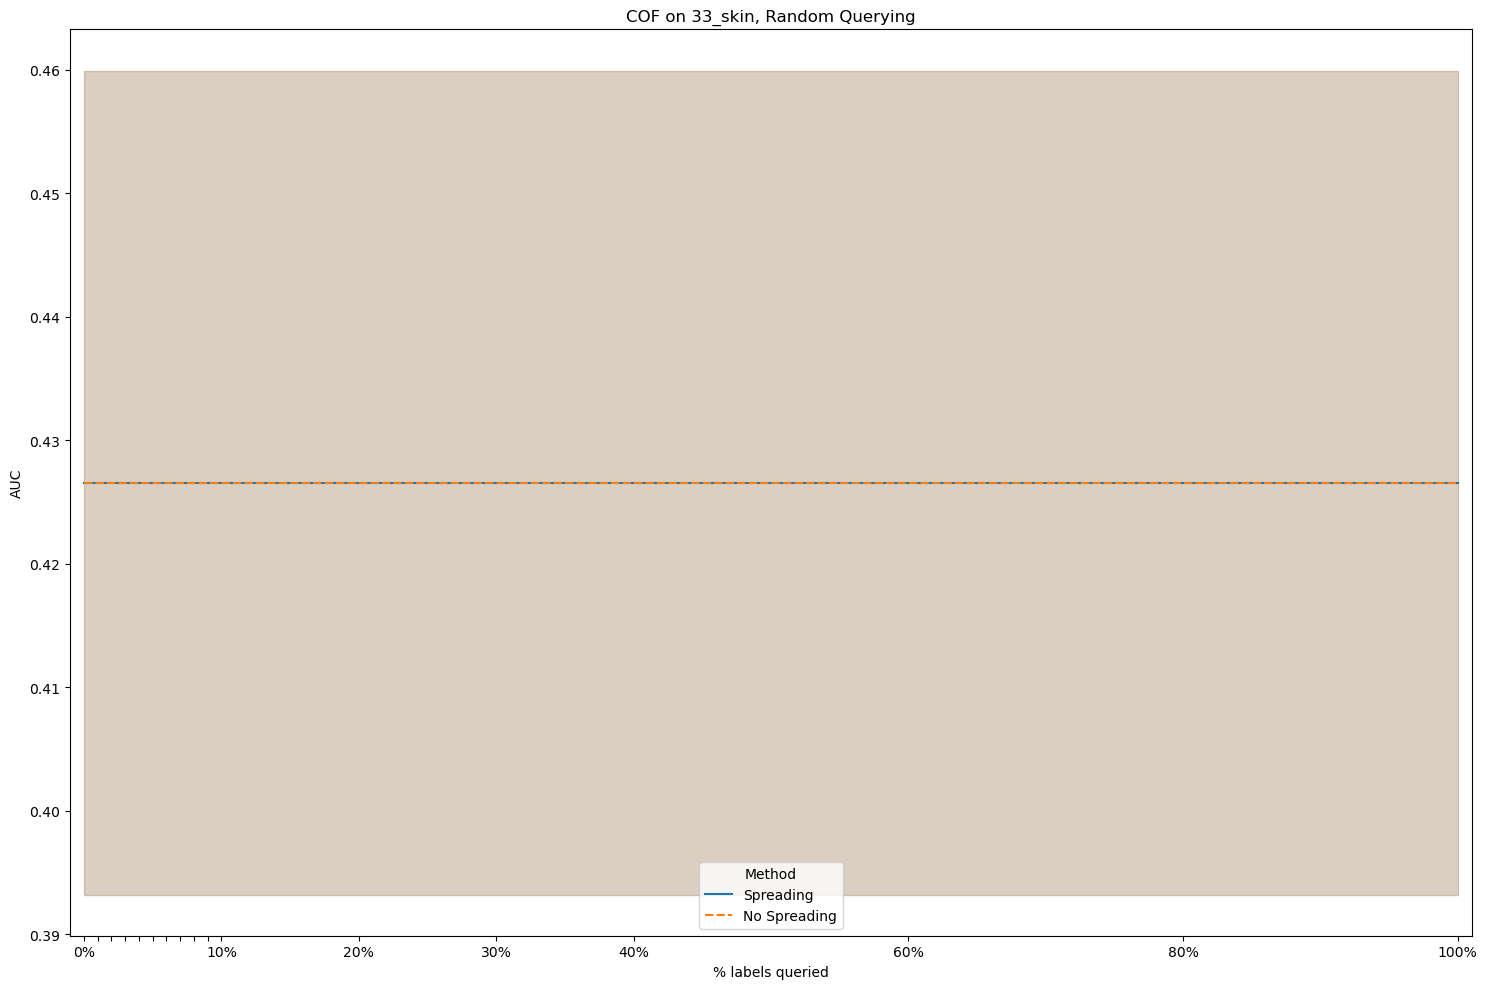

In [14]:
# method=fast/memory
# cof_model = COF(n_neighbors=5, method='memory')
cof_model = COF
cof_results_prop, cof_results_noprop = run_experiment(X, y, cof_model, "COF", fractions=fractions, params= {"method": "memory", "n_neighbors": 5})
plot_single_results_with_uncertainty(cof_results_prop, cof_results_noprop, fractions, "COF", dataset)

In [15]:
# sns.distplot(X[:, 0])

from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

  6%|█████████▏                                                                                                                                                  | 1/17 [00:02<00:43,  2.69s/it]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 17/17 [00:47<00:00,  2.82s/it]


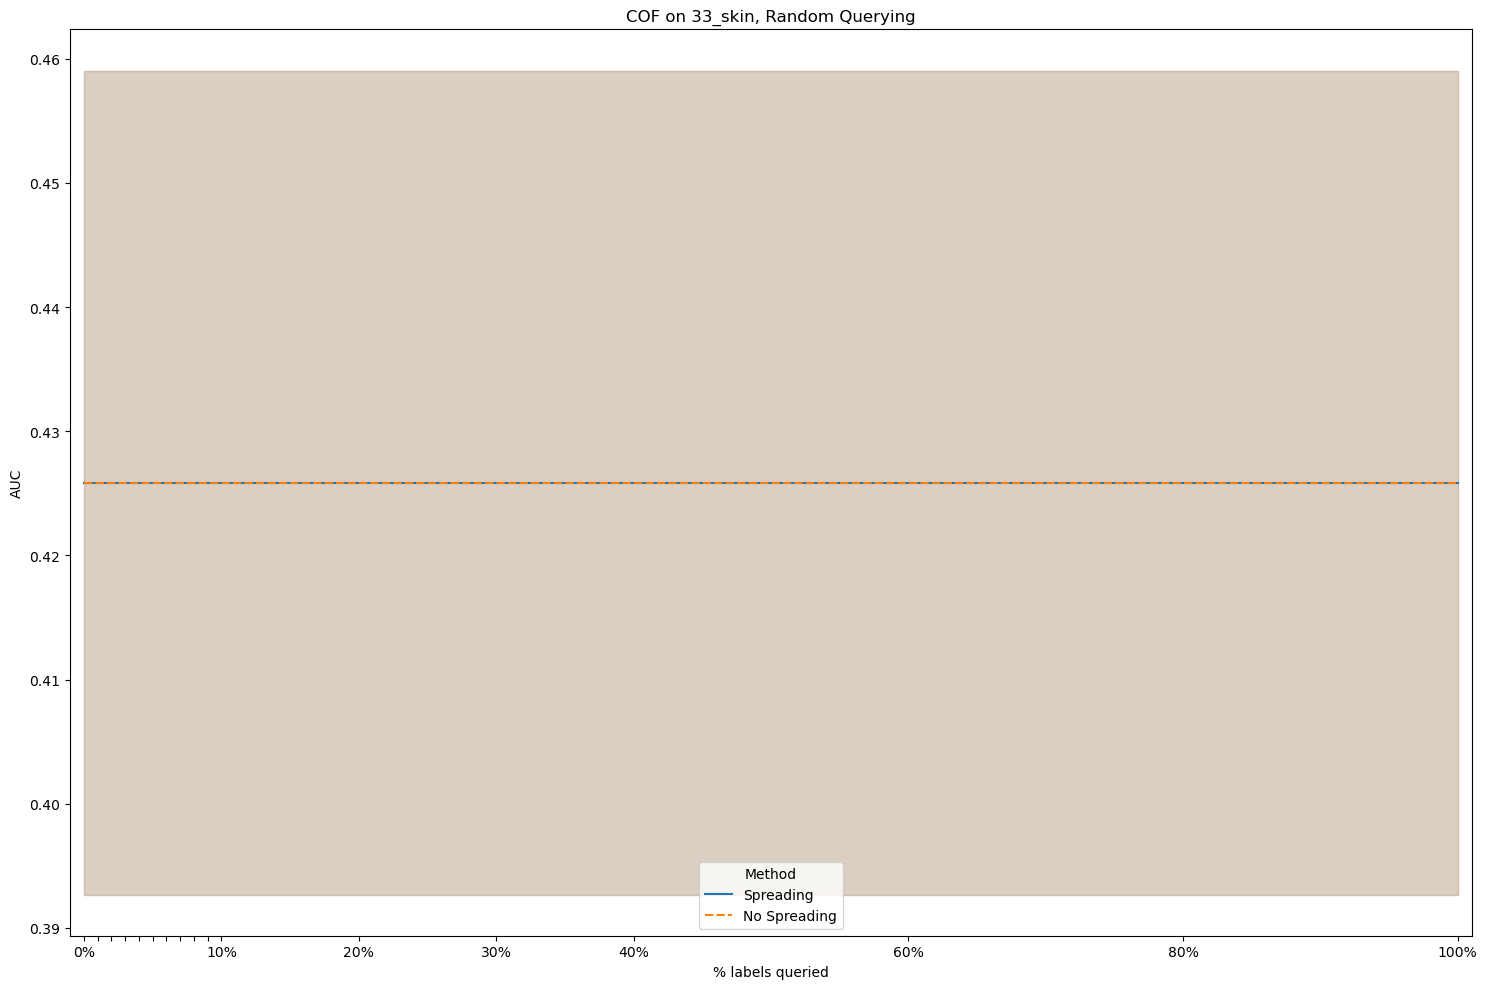

In [16]:
# scaled
cof_results_prop, cof_results_noprop = run_experiment(X_scaled, y, cof_model, "COF", fractions=fractions, params= {"method": "memory", "n_neighbors": 5})
plot_single_results_with_uncertainty(cof_results_prop, cof_results_noprop, fractions, "COF", dataset)

In [17]:
# run all dataset to check if the same is observed on them

In [18]:
# run for several dataset
dataset_subset = ['11_donors', '2_annthyroid', '6_cardio', '7_Cardiotocography']
fractions = [0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09,
                 0.1, 0.2, 0.3, 0.4, 0.6, 0.8, 1.0]
all_results = pd.DataFrame()
for dataset in dataset_subset:
    path = f'data/{dataset}.npz'
    data = np.load(path, allow_pickle=True)
    X, y = data['X'], data['y']
    for each_key, each_model in model_dict.items():
        all_results_prop, all_results_noprop = run_experiment(X, y, each_model, each_key, fractions=fractions)
        current_results = pd.concat([all_results_prop, all_results_noprop])
        #combine
        all_results = pd.concat([all_results, current_results])
    


  6%|█████████▏                                                                                                                                                  | 1/17 [00:01<00:25,  1.57s/it]

  6%|█████████▏                                                                                                                                                  | 1/17 [00:01<00:29,  1.84s/it]

  6%|█████████▏                                                                                                                                                  | 1/17 [00:01<00:26,  1.67s/it]

  6%|█████████▏                                                                                                                                                  | 1/17 [00:03<00:53,  3.36s/it]

  6%|█████████▏                                                                                                                                                  | 1/17 [00:01<00:25,  1.57s/it]

...

  6%|█████████▏                                                                                                                                                  | 1/17 [00:01<00:24,  1.55s/it]

  6%|█████████▏                                                                                                                                                  | 1/17 [00:00<00:08,  1.88it/s]

  6%|█████████▏                                                                                                                                                  | 1/17 [00:00<00:09,  1.69it/s]

 12%|██████████████████▎                                                                                                                                         | 2/17 [00:00<00:07,  1.98it/s]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 17/17 [00:09<00:00,  1.77it/s]


In [22]:
all_results["dataset"].unique().tolist()

['11_donors', '2_annthyroid', '6_cardio', '7_Cardiotocography']

In [23]:
all_results[all_results["dataset"]=="6_cardio"]

,method,dataset,model,roc_auc,fraction,rep
0,Spreading,6_cardio,PCA,NaN,0.0,0
0,Spreading,6_cardio,PCA,NaN,0.0,1
0,Spreading,6_cardio,PCA,NaN,0.0,2
0,Spreading,6_cardio,PCA,NaN,0.0,3
0,Spreading,6_cardio,PCA,NaN,0.0,4
...,...,...,...,...,...,...
0,No Spreading,6_cardio,CBLOF,0.931923,1.0,0
0,No Spreading,6_cardio,CBLOF,0.957227,1.0,1
0,No Spreading,6_cardio,CBLOF,0.969027,1.0,2
0,No Spreading,6_cardio,CBLOF,0.944045,1.0,3


DOne for dataset  11_donors


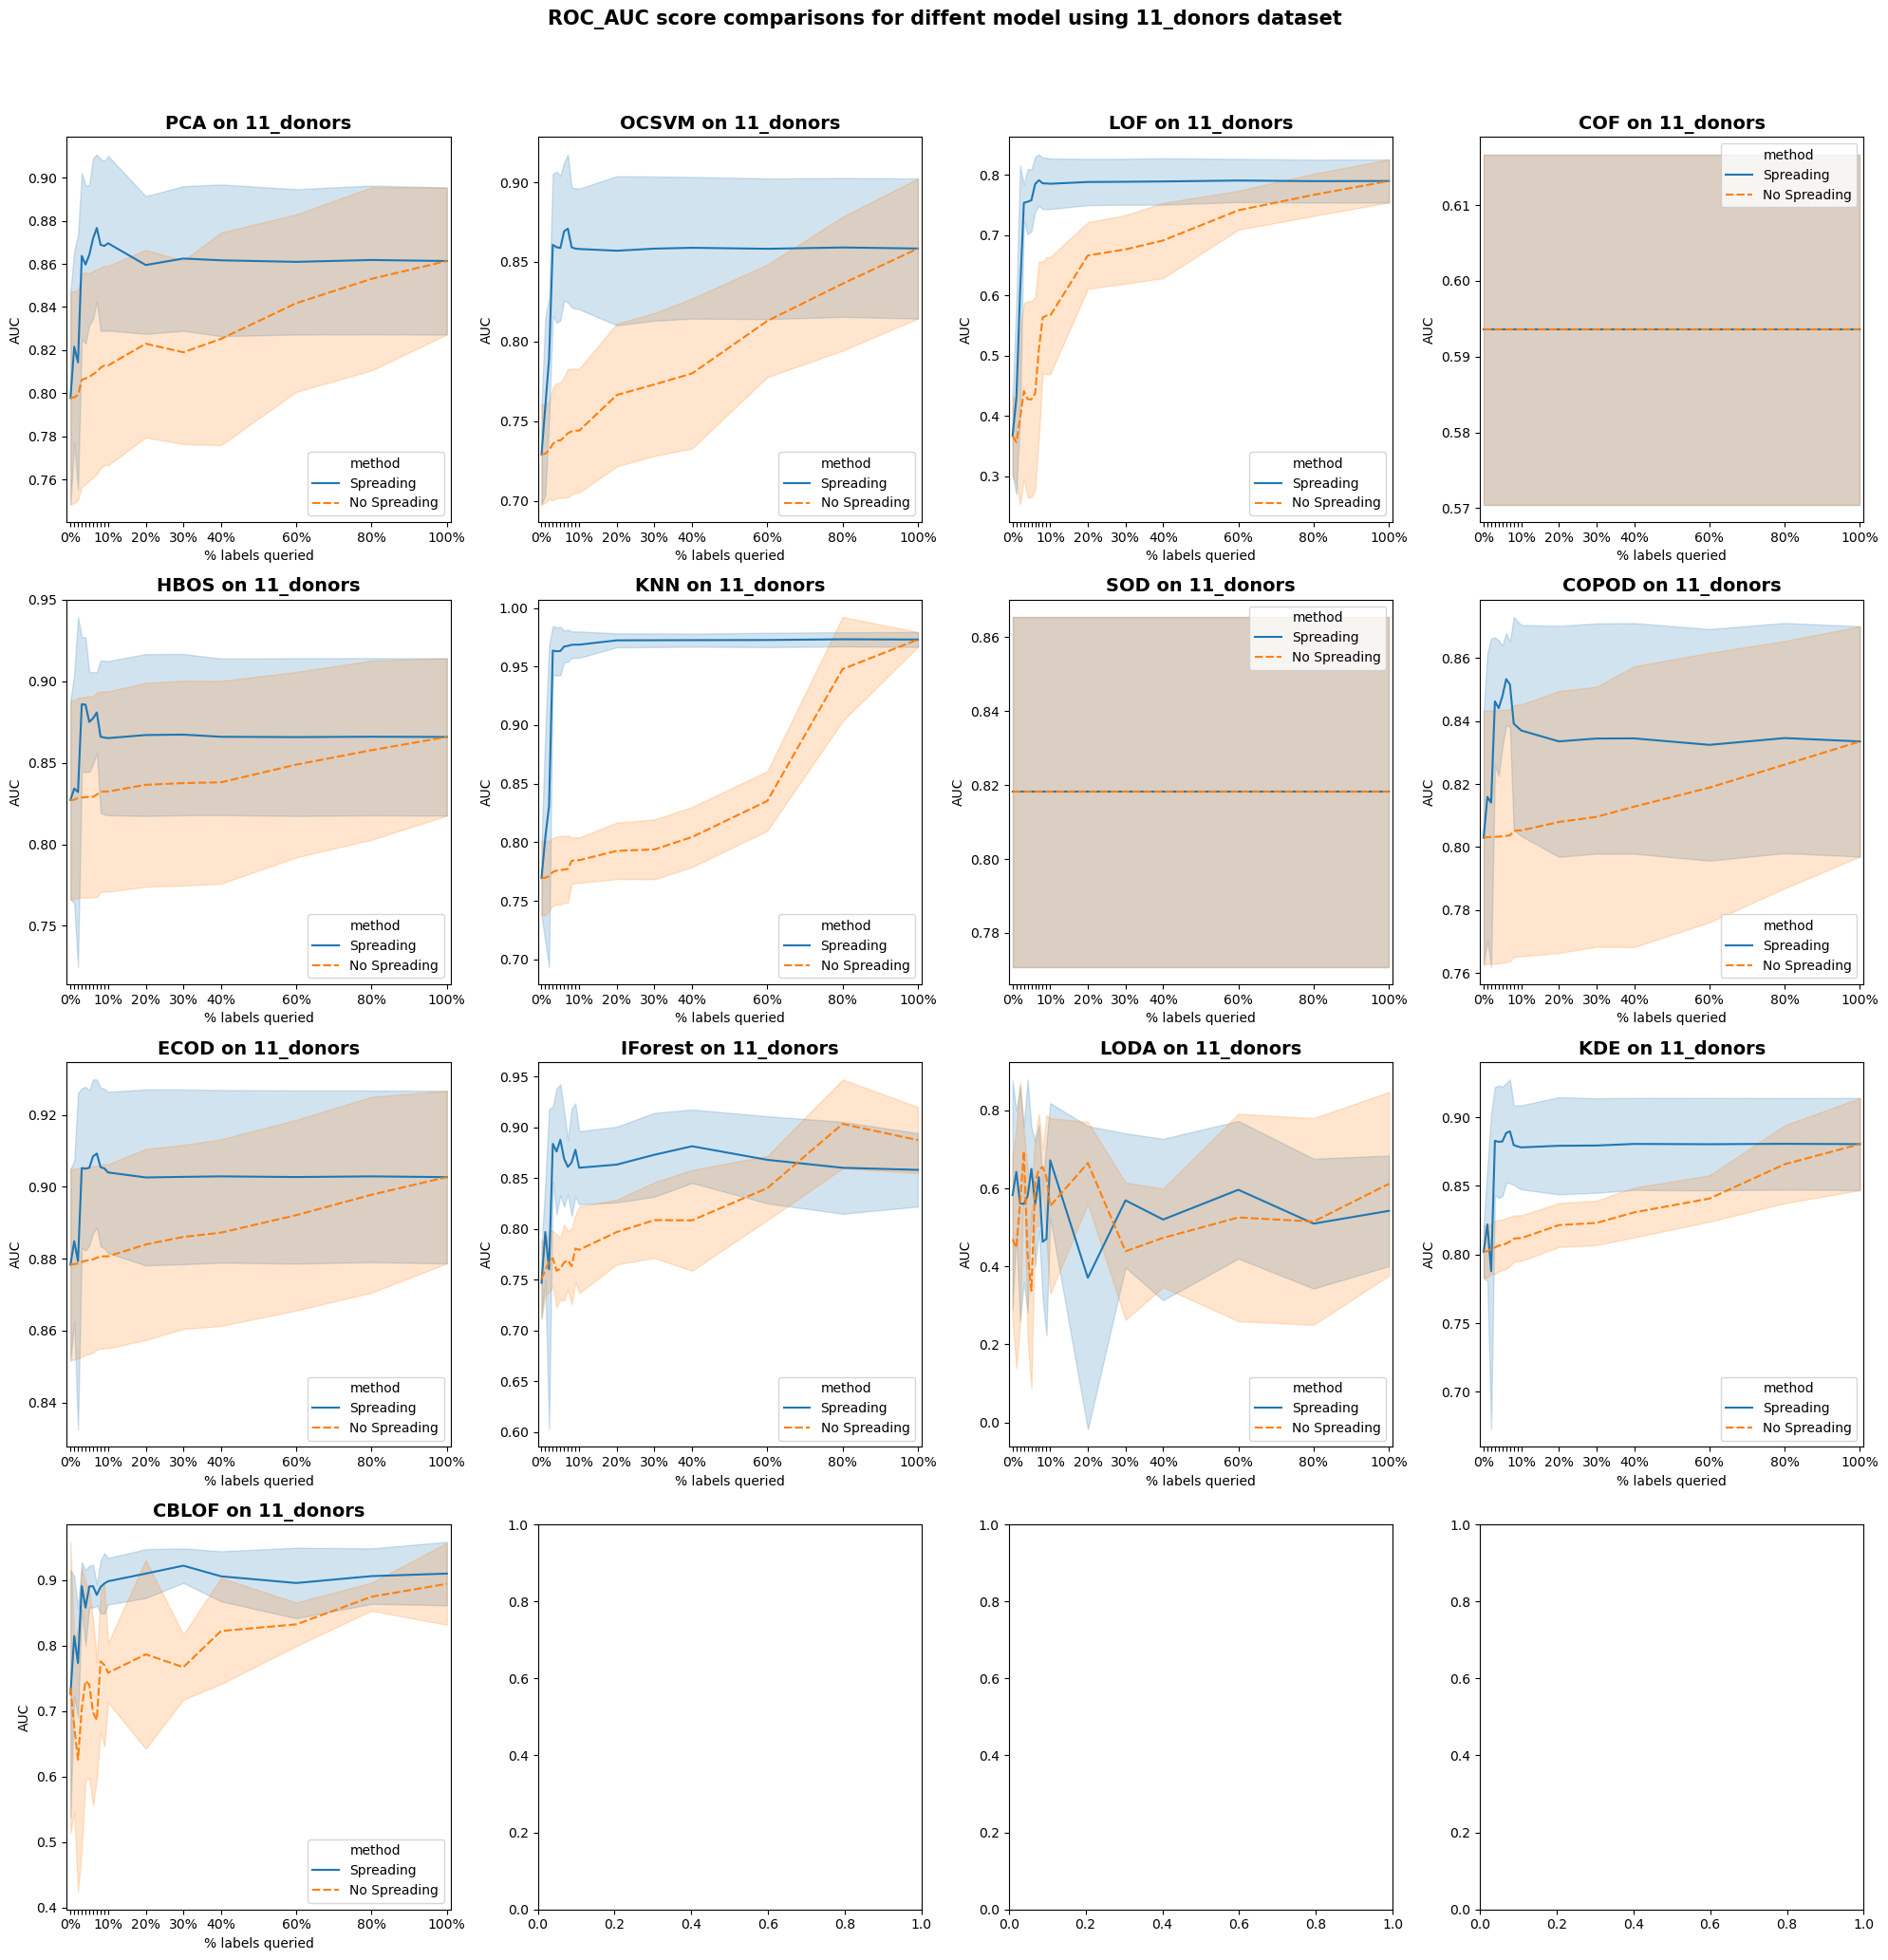

DOne for dataset  2_annthyroid


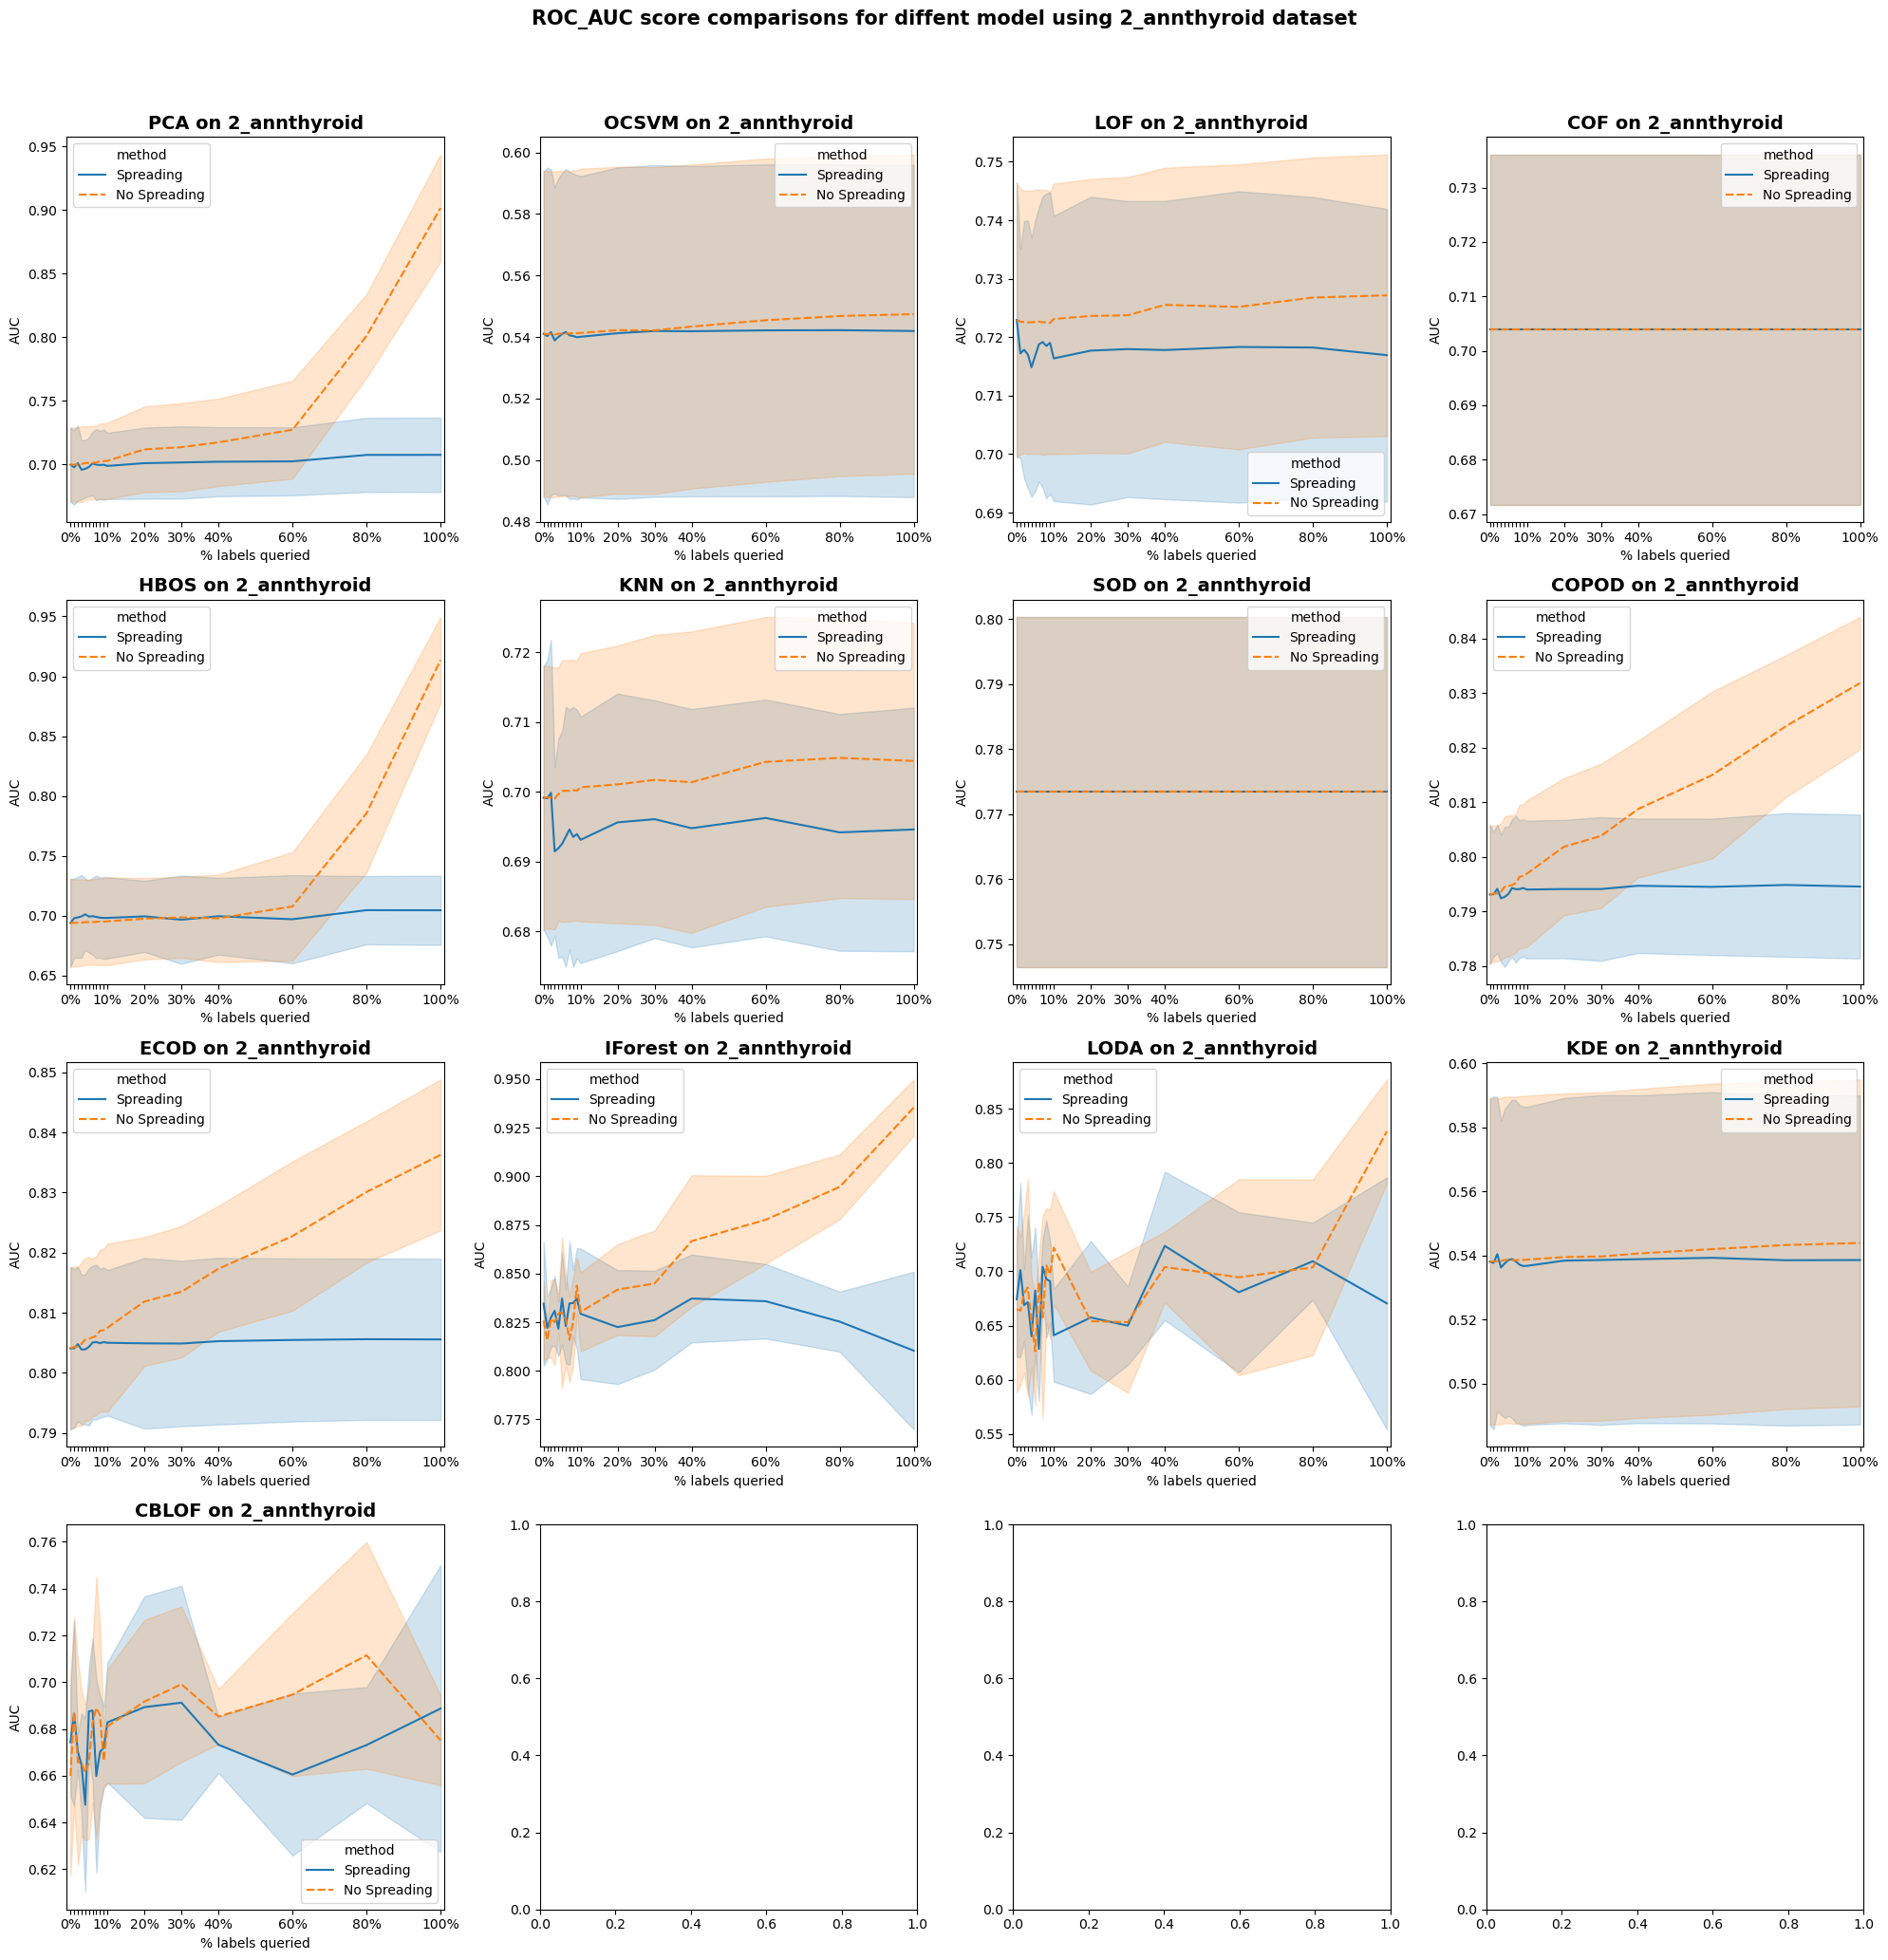

DOne for dataset  6_cardio


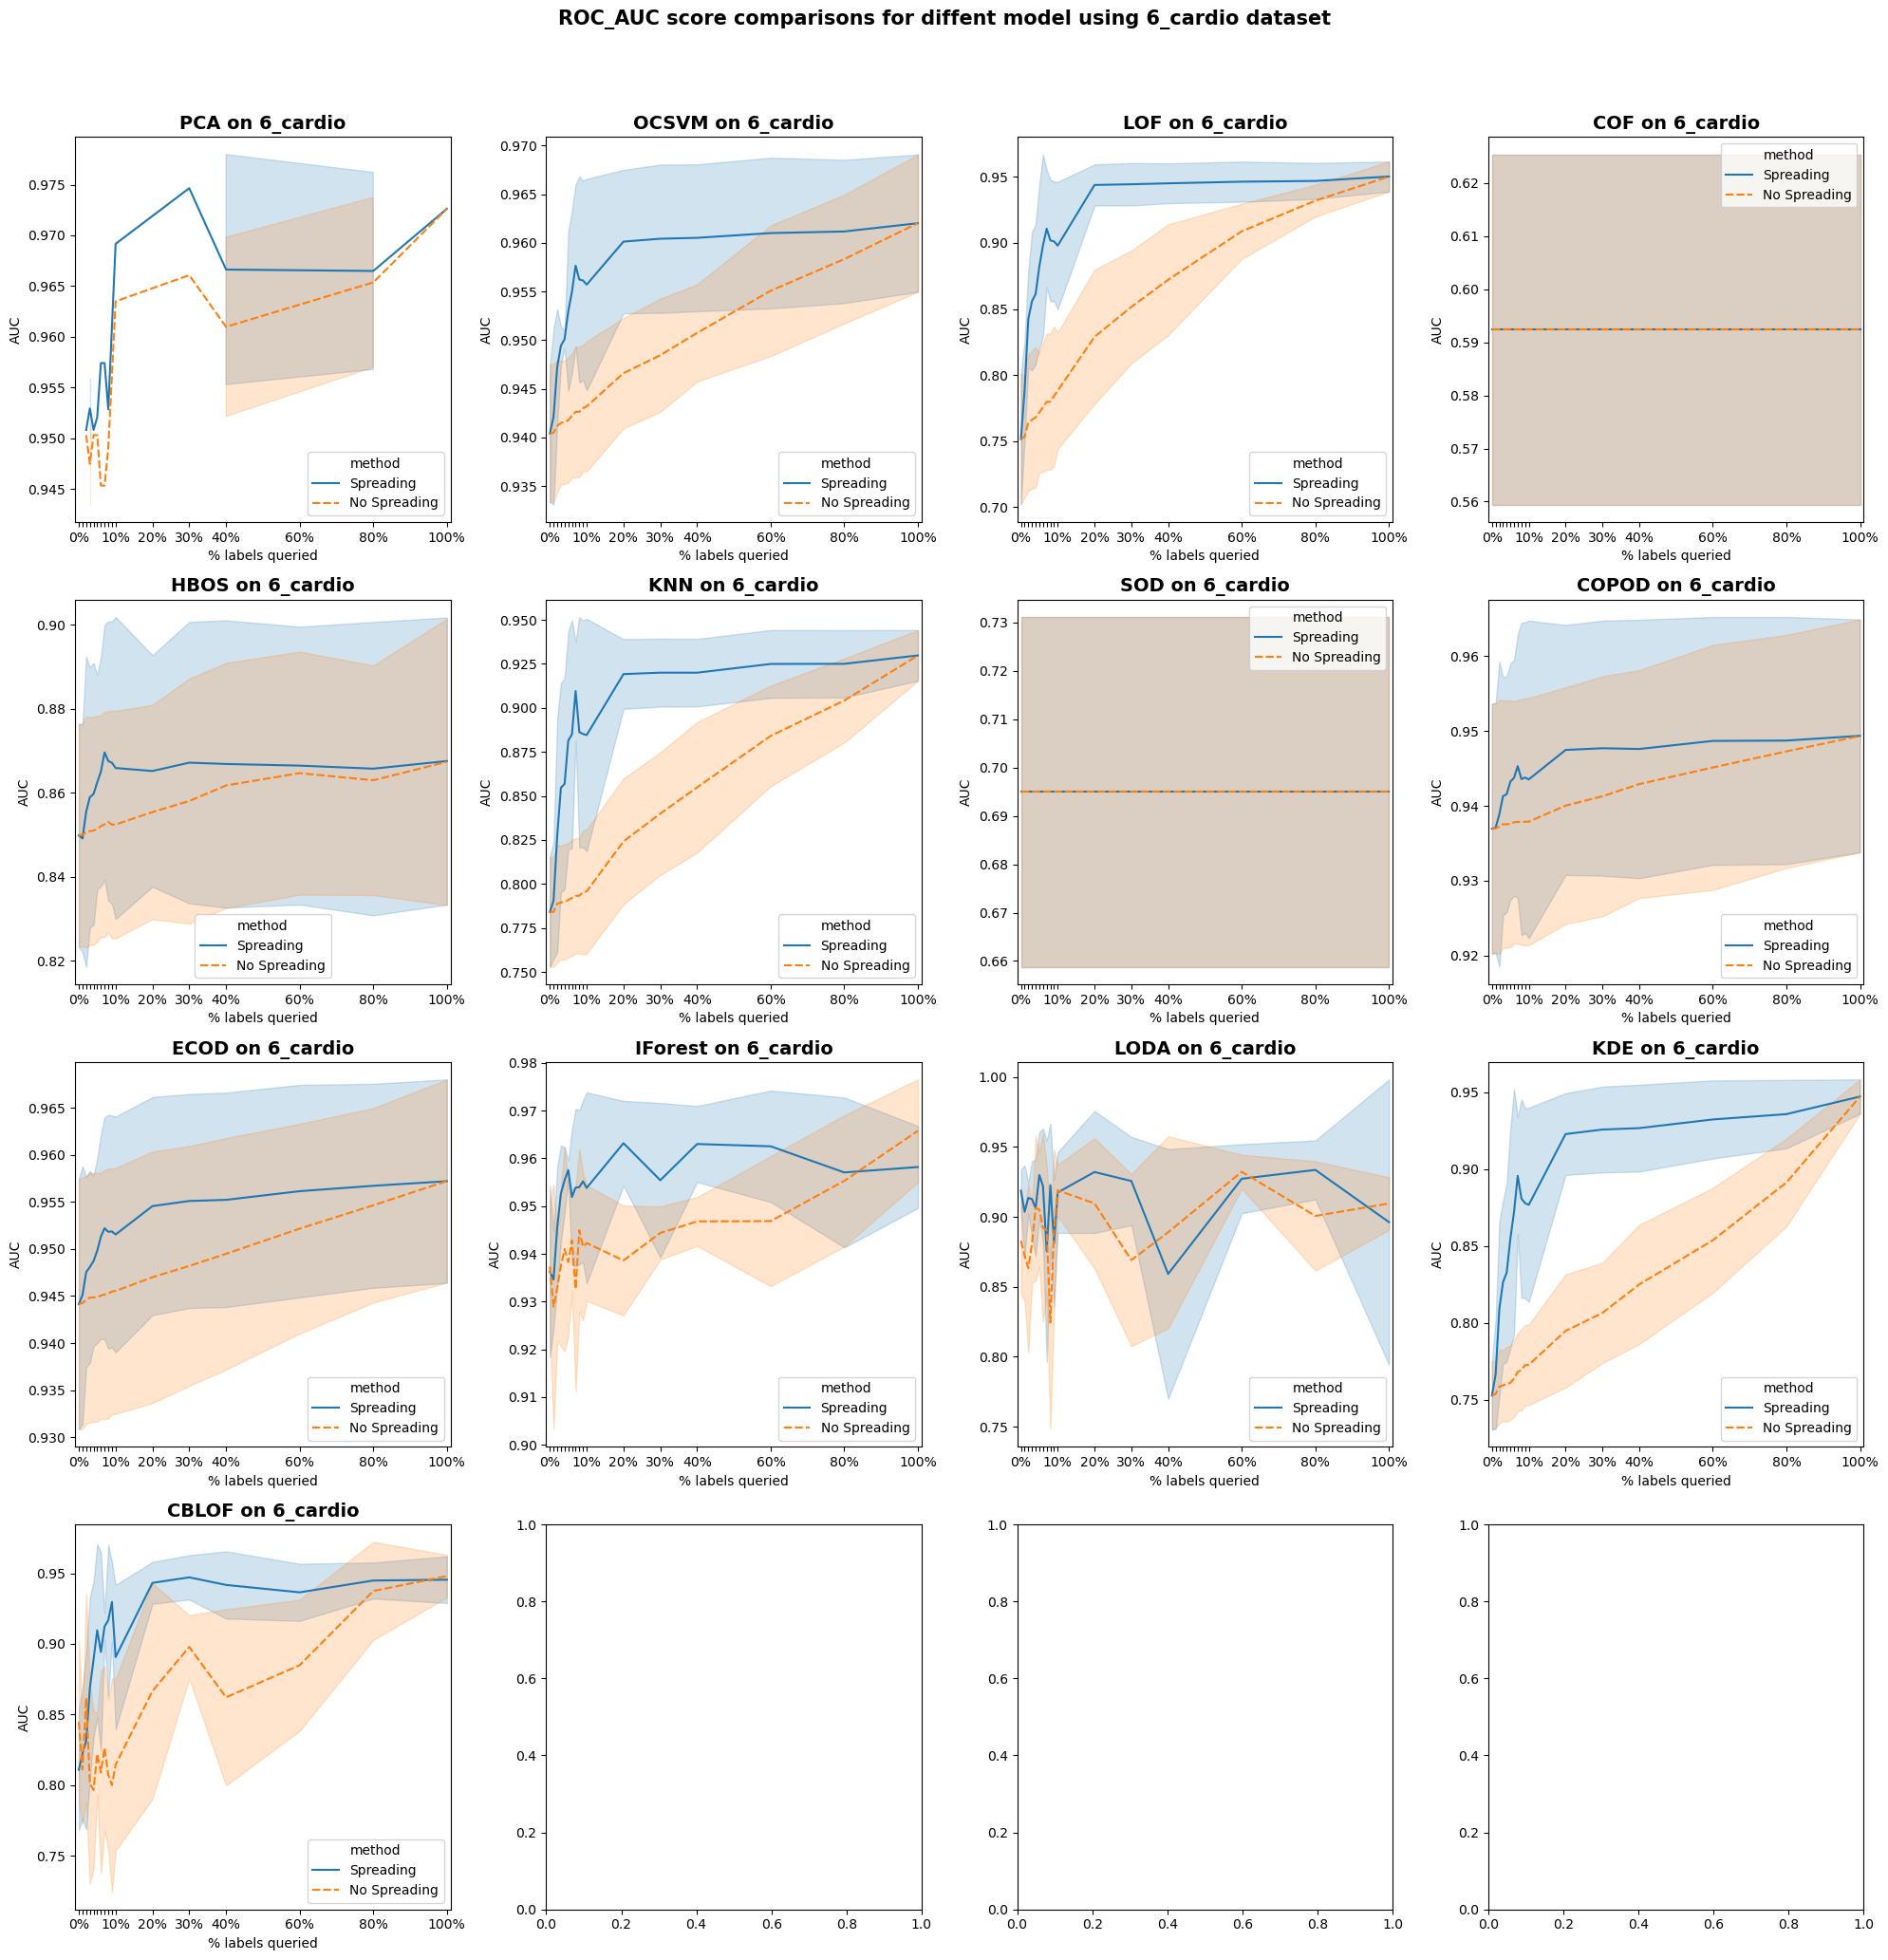

DOne for dataset  7_Cardiotocography


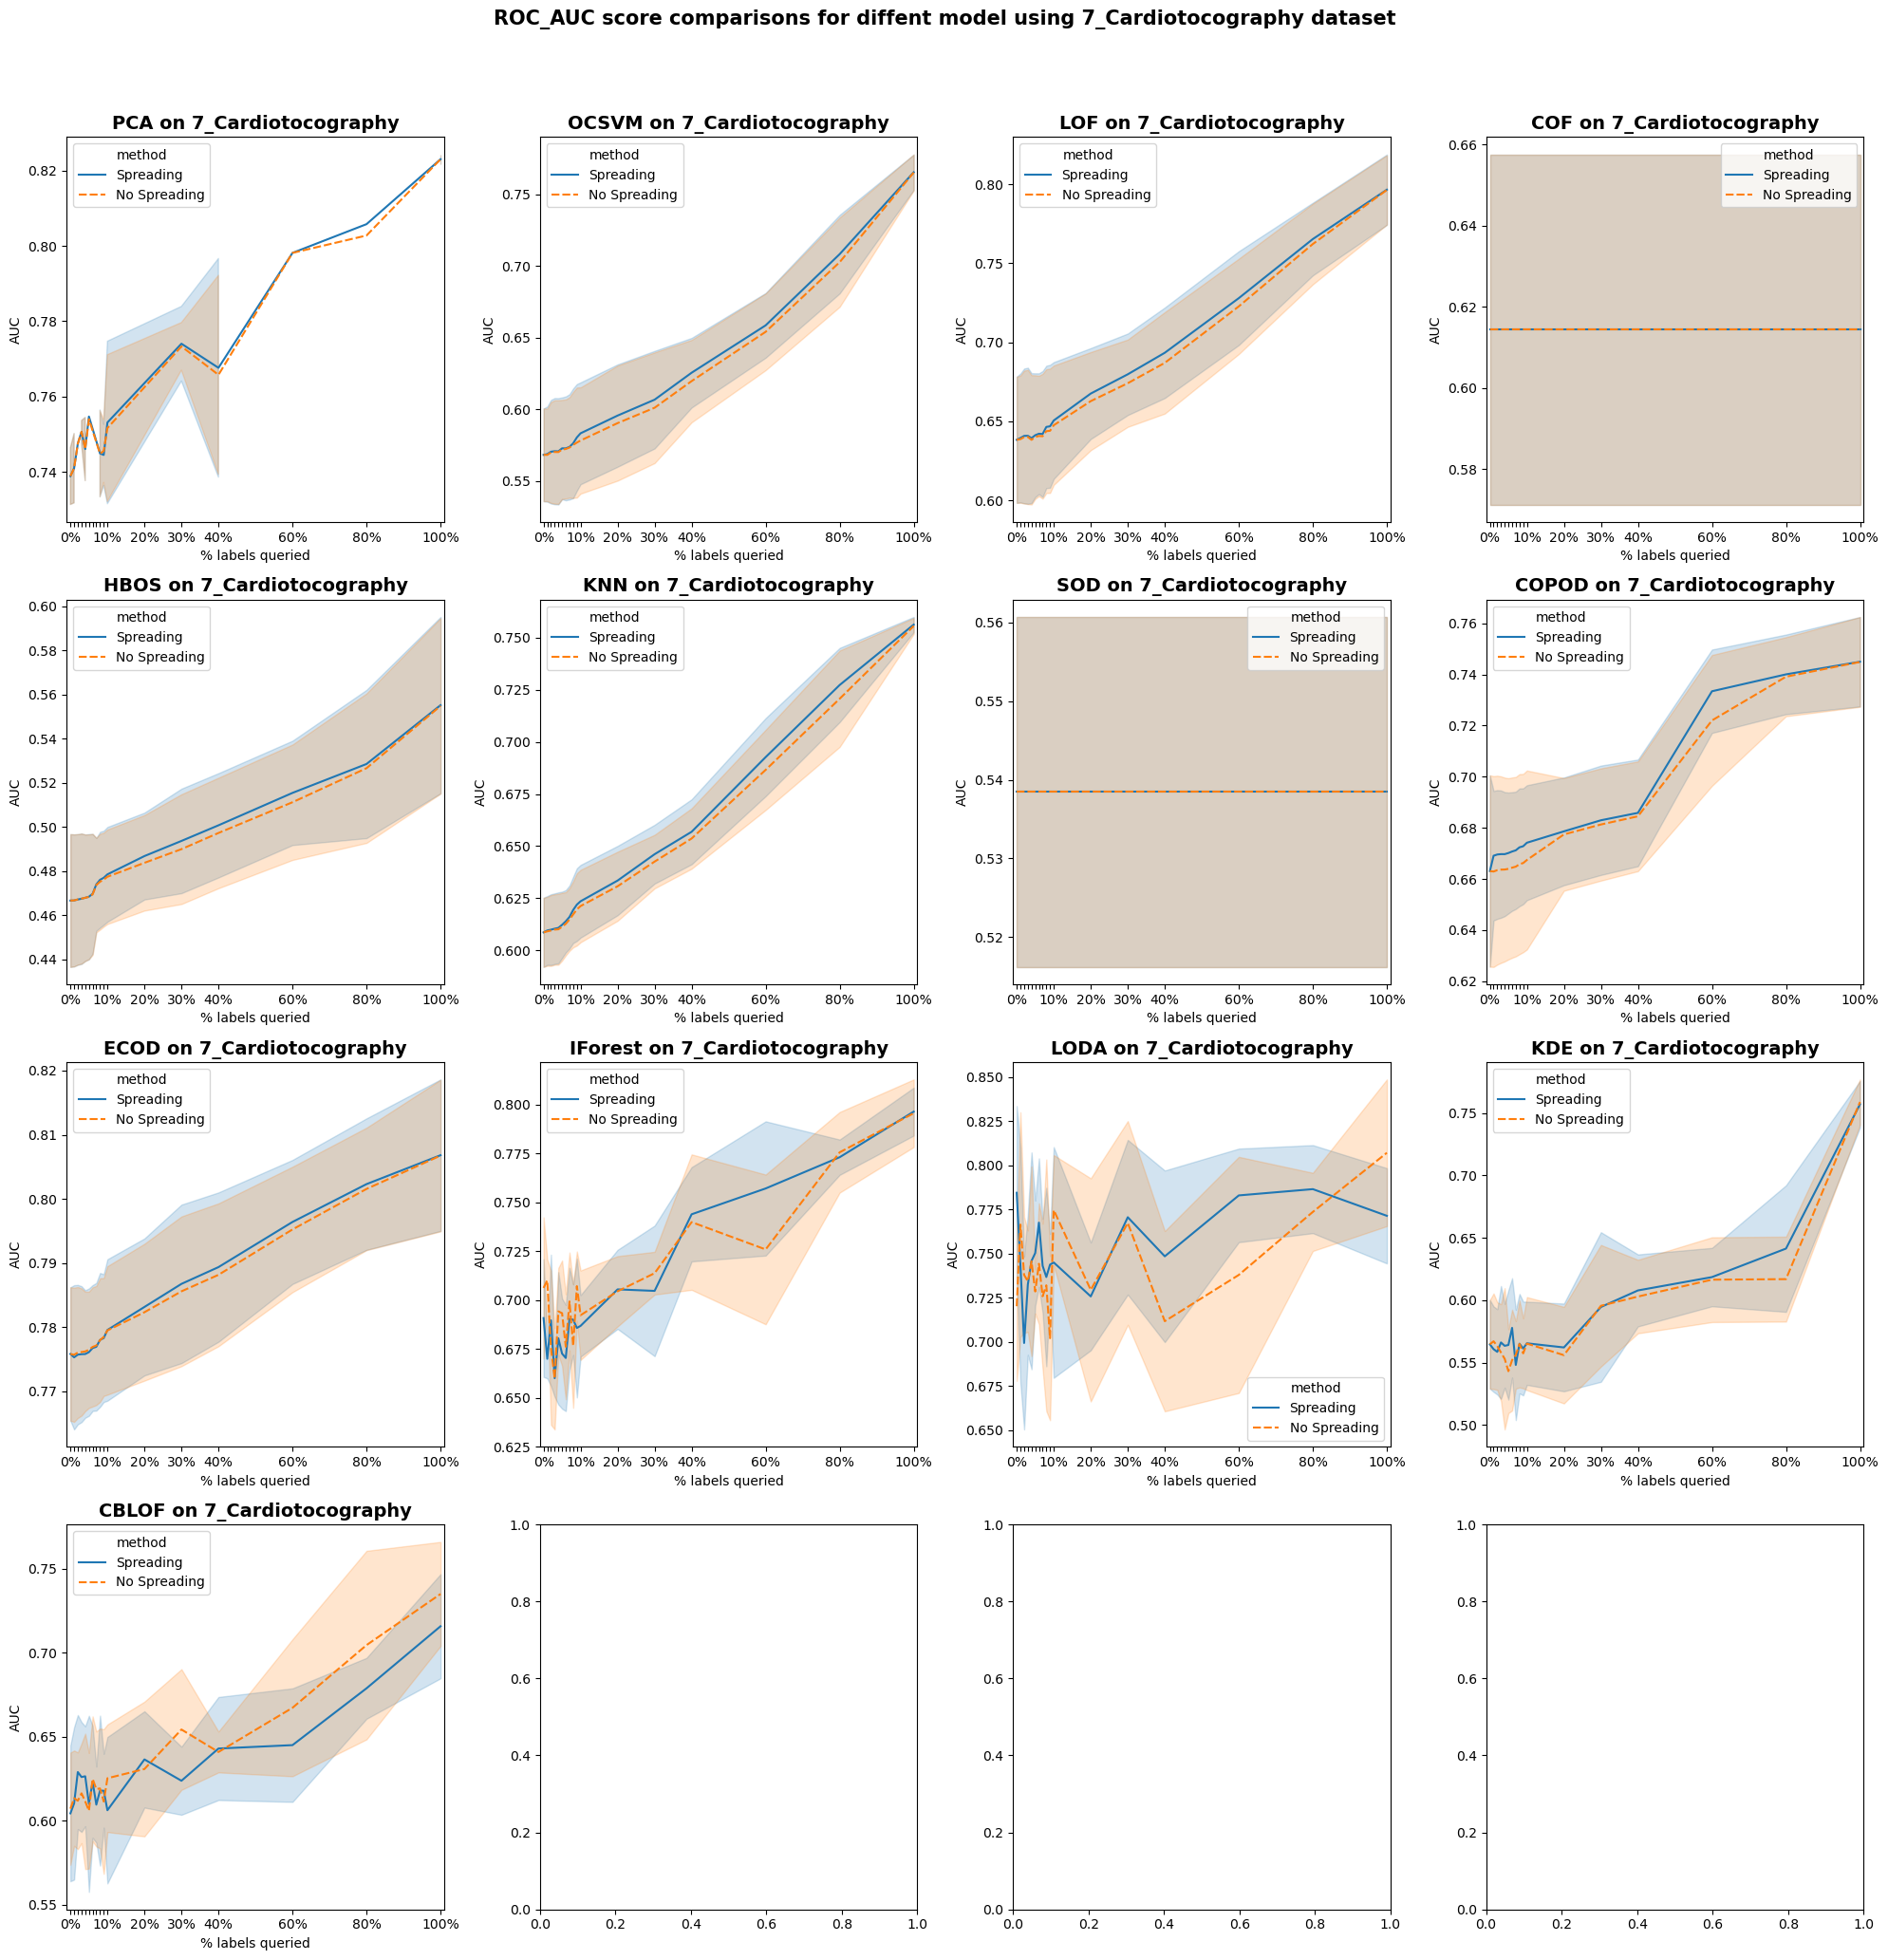

In [27]:
# plot the results
plot_results_grid(all_results, fractions, model_dict, all_results["dataset"].unique().tolist())